  battery_id  cycle       chI       chV        chT      disI      disV  \
0         B5      1  1.440147  4.254682  23.988733  1.894407  3.273523   
1         B5      2  1.416595  4.159825  25.665347  1.829949  4.038741   
2         B5      3  1.420272  4.276323  25.407910  1.942105  3.214433   
3         B5      4  1.337680  4.236697  27.069757  2.073577  3.134529   
4         B5      5  1.263946  4.142791  26.478353  2.049885  3.729341   

        disT       BCt        SOH  RUL  
0  32.980834  1.986196  99.309790  219  
1  32.257920  1.986240  99.311985  218  
2  35.134801  1.984252  99.212608  217  
3  32.082988  1.969236  98.461812  216  
4  32.483154  1.974862  98.743106  215  
<class 'pandas.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   battery_id  680 non-null    str    
 1   cycle       680 non-null    int64  
 2   chI         680 non-null    float64
 3   chV  

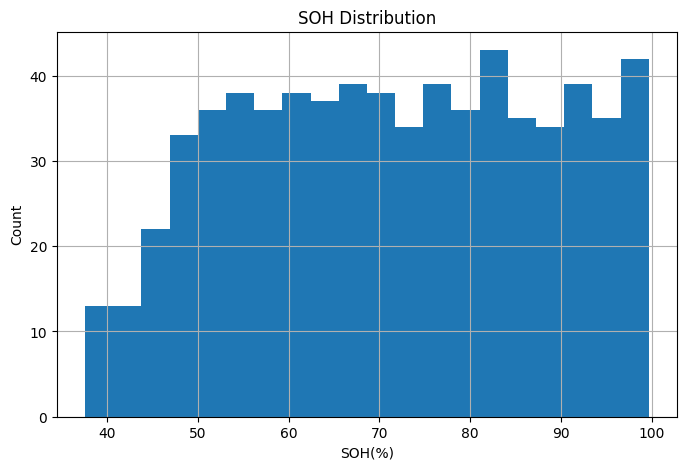

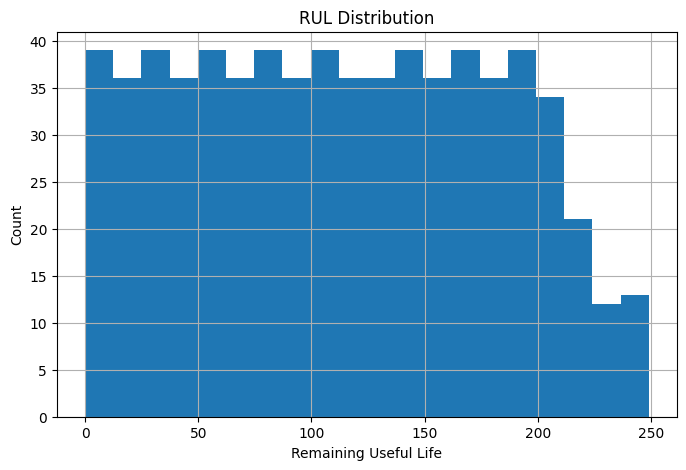

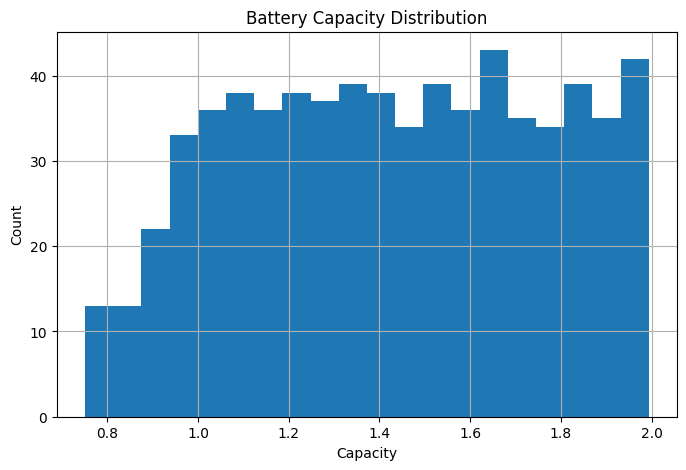

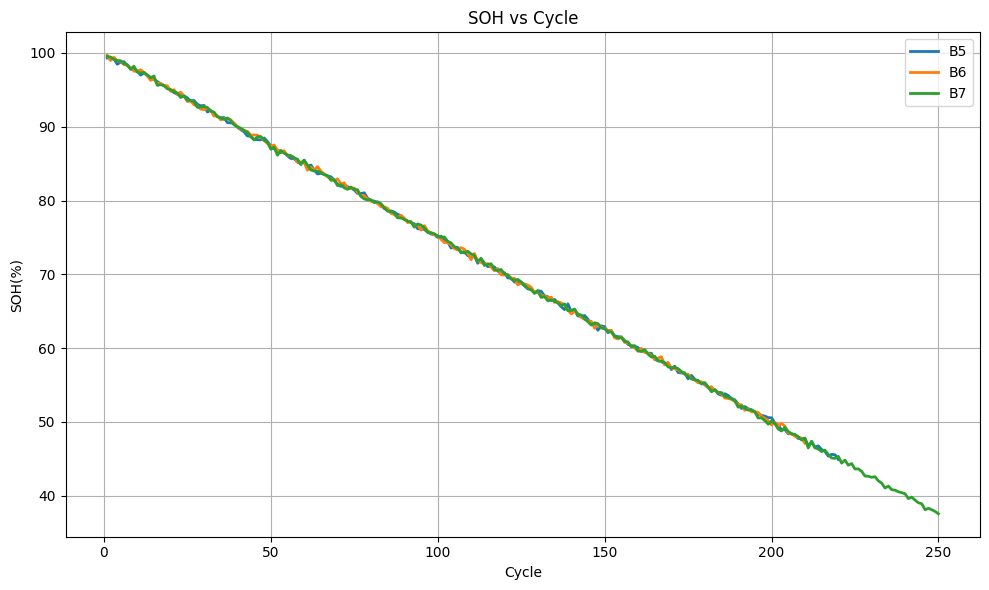

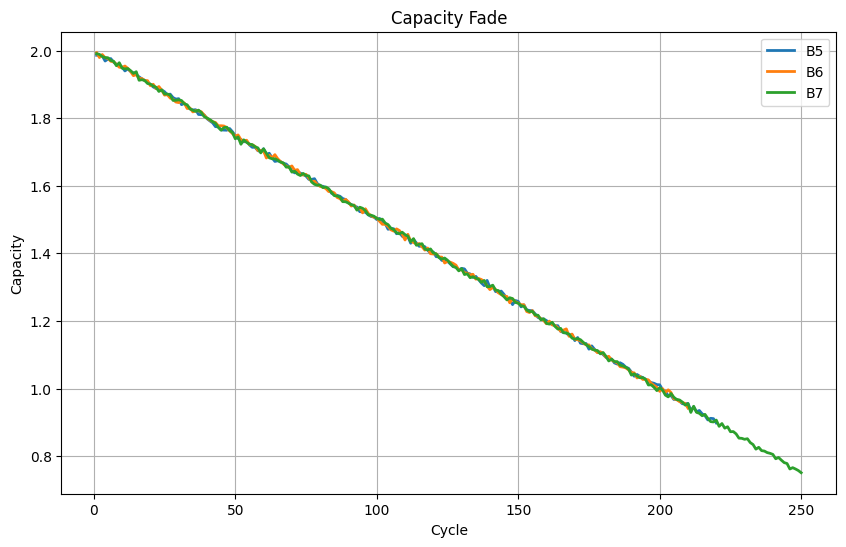

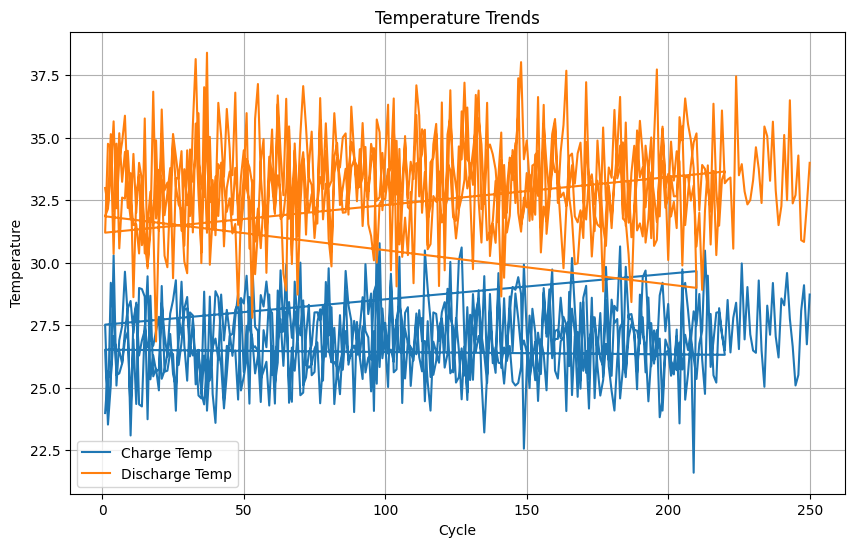

                  SOH    RUL       BCt    Status
battery_id                                      
B5          72.385157  109.5  1.447703   Warning
B6          73.645500  104.5  1.472910   Warning
B7          68.626618  124.5  1.372532  Critical
                  SOH    RUL       BCt    Status
battery_id                                      
B7          68.626618  124.5  1.372532  Critical
B5          72.385157  109.5  1.447703   Warning
B6          73.645500  104.5  1.472910   Warning


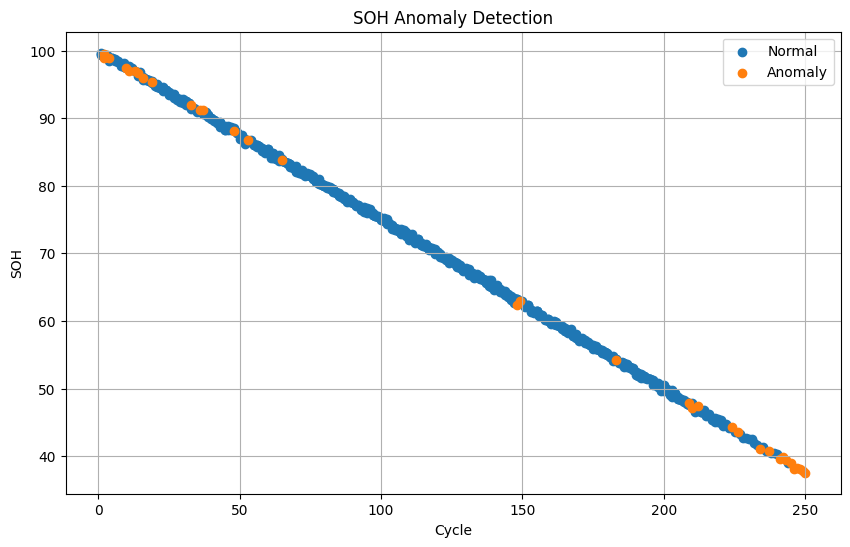

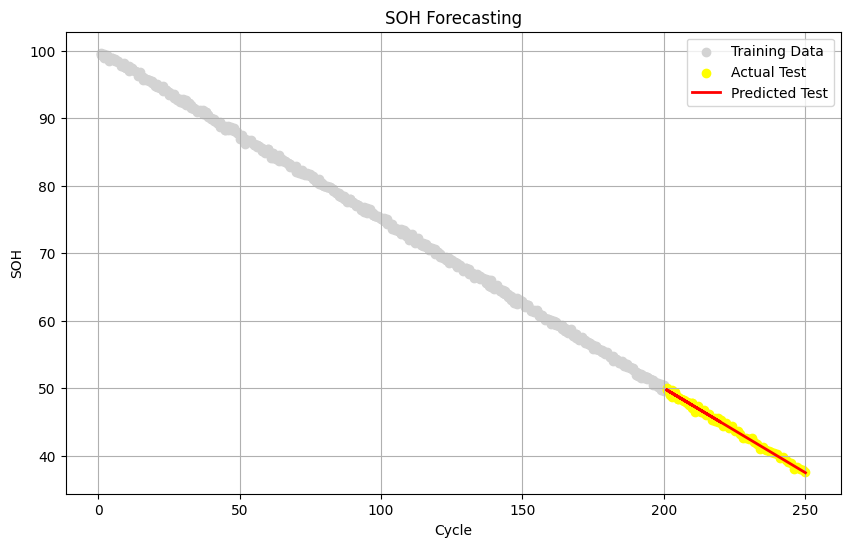

MAE: 0.20324078200648144
R²: 0.9948264691968174
                  SOH    RUL    Status      Recommendation
battery_id                                                
B5          72.385157  109.5   Warning  Inspect or Replace
B6          73.645500  104.5   Warning  Inspect or Replace
B7          68.626618  124.5  Critical  Inspect or Replace


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("Battery_dataset.csv")

print(df.head())
print(df.info())
print(df.describe())

print("\nMissing values")
print(df.isnull().sum())

print("\nDuplcates")
print(df.duplicated().sum())

print("Number of Batteries:", df["battery_id"].nunique())

print("Number of Records:", len(df))

fleet_summary = df.groupby("battery_id").agg(
    {
        "SOH":"mean",
        "RUL":"mean",
        "BCt":"mean"
    } )
print(fleet_summary)

plt.figure(figsize=(8,5))

plt.hist(df["SOH"], bins = 20)

plt.title("SOH Distribution")
plt.xlabel("SOH(%)")
plt.ylabel("Count")

plt.grid(True)

plt.savefig("SOH_Distribution.png")

plt.show()

plt.figure(figsize=(8,5))

plt.hist(df["RUL"],  bins =20)

plt.title("RUL Distribution")
plt.xlabel("Remaining Useful Life")
plt.ylabel("Count")

plt.savefig("RUL_Distribution.png")

plt.grid(True)


plt.show()


plt.figure(figsize=(8,5))

plt.hist(df["BCt"], bins = 20)

plt.title("Battery Capacity Distribution")
plt.xlabel("Capacity")

plt.savefig("Battery_Capacity_Distribution.png")

plt.ylabel("Count")

plt.grid(True)

plt.show()

plt.figure(figsize=(10,6))

for battery in df["battery_id"].unique():

    subset = df[df["battery_id"] == battery]

    plt.plot(
        subset["cycle"],
        subset["SOH"],
        label = battery,
        linewidth = 2
    ) 

plt.title("SOH vs Cycle")

plt.xlabel("Cycle")
plt.ylabel("SOH(%)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("SOH_vs_Cycle.png")

plt.show()

plt.figure(figsize=(10,6))

for battery in df["battery_id"].unique():

    subset = df[df["battery_id"] == battery]

    plt.plot(
        subset["cycle"],
        subset["BCt"],
        label =battery,
        linewidth = 2
    )

plt.title("Capacity Fade")

plt.xlabel("Cycle")
plt.ylabel("Capacity")

plt.legend()

plt.grid(True)

plt.savefig("Capacity_Fade_Comparison.png")

plt.show()

charge_fit = np.polyfit(df["cycle"], df["chT"], 1)

charge_trend = np.poly1d(charge_fit)

charge_trend_values = charge_trend(df["cycle"])

discharge_fit = np.polyfit(df["cycle"], df["disT"], 1)

discharge_trend = np.poly1d(discharge_fit)

discharge_trend_values = discharge_trend(df["cycle"]) 

plt.figure(figsize=(10,6))

plt.plot(
    df["cycle"],
    df["chT"],
    label = "Charge Temp"
)

plt.plot(
    df["cycle"],
    df["disT"],
    label = "Discharge Temp",
    )


plt.title("Temperature Trends")

plt.xlabel("Cycle")
plt.ylabel("Temperature")

plt.legend()

plt.grid(True)

plt.savefig("Temperature_Trends.png")

plt.show()

def classify_battery(soh):

    if soh > 80:
        return "Healthy"
    
    elif soh >70:
        return "Warning"
    
    else:
        return "Critical"
    
fleet_summary["Status"] = \
fleet_summary["SOH"].apply(classify_battery) 

print(fleet_summary)


ranked = fleet_summary.sort_values(
    by= "SOH"
)

print(ranked)


features = df[
    [
        "SOH",
        "BCt",
        "chT",
        "disT"
    ]
    ]

model = IsolationForest(
    contamination = 0.05,
    random_state= 42
)

df["Anomaly"] = model.fit_predict(
    features
)


plt.figure(figsize=(10,6))

normal = df[df["Anomaly"] == 1]

anomaly = df[df["Anomaly"] == -1]

plt.scatter(
    normal["cycle"],
    normal["SOH"],
    label = "Normal"
)

plt.scatter(
    anomaly["cycle"],
    anomaly["SOH"],
    label = "Anomaly"
)

plt.legend()

plt.title("SOH Anomaly Detection")

plt.xlabel("Cycle")
plt.ylabel("SOH")

plt.grid(True)

plt.savefig("SOH_Anomaly_Detection.png")

plt.show()

train = df[df["cycle"] <= 200]
test = df[df["cycle"] > 200]

X_train = train[["cycle"]]
y_train = train["SOH"]

X_test = test[["cycle"]]
y_test = test["SOH"]

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)


plt.figure(figsize=(10,6))

plt.scatter(
    train["cycle"],
    train["SOH"],
    color = "lightgray",
    label = "Training Data"
)

plt.scatter(
    X_test["cycle"],
    y_test,
    color = "yellow",
    label = "Actual Test"
)

plt.plot(
    X_test["cycle"],
    predictions,
    color = "red",
    linewidth = 2,
    label = "Predicted Test"
)

plt.title("SOH Forecasting")
plt.xlabel("Cycle")
plt.ylabel("SOH")

plt.legend()

plt.grid(True)

plt.savefig("SOH_Forecasting.png")

plt.show()

print("MAE:", mean_absolute_error(y_test, predictions))
print("R²:", r2_score(y_test, predictions))

def recommendation(row):

    if row["SOH"] < 80:
        return "Inspect or Replace"
    
    elif row["SOH"] < 90:
        return "Monitor Closely"
    
    else:
        return "Normal Operation"
    
fleet_summary["Recommendation"] = \
fleet_summary.apply(
    recommendation,
    axis = 1
)

print(
    fleet_summary[
        [
            "SOH",
            "RUL",
            "Status",
            "Recommendation"
        ]
        ]
      )


fleet_summary.to_csv(
    "battery_health_report.csv"
)